In [1]:
#加载必要的库
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import datasets, transforms,models
import os 
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [2]:
#定义一个方法：显示图片
def image_show(inp, title=None,save_name=None):
    plt.figure(figsize=(12,36)) #设置画布
    inp = inp.numpy().transpose((1,2,0)) #张量转数组，调整维度顺序（在pytorch中顺序为channel,height,width;而matploylib中顺序为h,w,c）
    mean = np.array([0.485,0.456,0.406]) #定义均值
    std = np.array([0.229,0.224,0.225]) #定义标准差
    inp = std*inp + mean #还原标准化图片像素值
    inp = np.clip(inp,0,1) #裁剪像素值
    plt.imshow(inp) #绘制图片到画布
    if title is not None:
        plt.title(title)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=300)        
    plt.show()
    
    

In [3]:
#更改池化层
class AdaptiveConcatPool2d(nn.Module):
    def __init__(self,size=None):
        super().__init__()
        size = size or (1,1) #池化层的卷积核大小，默认为（1，1）
        self.pool_one = nn.AdaptiveAvgPool2d(size) #池化层1：计算区域内的平均值，保留整体信息
        self.pool_two = nn.AdaptiveMaxPool2d(size) #池化层2：提取区域内的最大值，保留显著特征

    def forward(self,x):
        return torch.cat([self.pool_one(x),self.pool_two(x)],1)
        

In [4]:
#迁移学习：在成熟模型的基础上进行微调
def get_model():
    model_pre = models.resnet50(weights = 'DEFAULT') #获取预训练模型
    #冻结预训练模型中的所有参数
    for param in model_pre.parameters():
        param.requires_grad = False
    #微调模型，替换Resnet最后的两层网络
    model_pre.avgpool = AdaptiveConcatPool2d () #池化层替换
    model_pre.fc = nn.Sequential( #修改全连接层
        nn.Flatten(),#所有维度拉平
        nn.BatchNorm1d(4096), #Resnet50中最后一层的输出维度是2048，把两层拼接在一起
        nn.Linear(4096,1024), #线形层的处理，压缩维度，提取更高级的特征，1024可替换
        nn.ReLU(), #激活层
        nn.Dropout(0.5), #丢掉一些神经元,防止过拟合
        nn.BatchNorm1d(1024), #标准化处理
        nn.Linear(1024,512), #重复前面的过程
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512,2)
    )
    return model_pre


In [5]:
#定义超参数
BATCH_SIZE = 32 #每批处理的数据数量
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
def main():
    #图片转换
    data_transforms = {
        'train':
            transforms.Compose([
                transforms.Resize(256), #设置图片大小
                transforms.RandomResizedCrop(224), 
                transforms.RandomHorizontalFlip(), #以50%的概率对图片进行翻转
                transforms.RandomRotation(15),#模拟拍摄时的轻微旋转
                transforms.ToTensor(), #转换为张量
                transforms.Normalize([0.485,0.456,0.406],
                                    [0.229,0.224,0.225])
            ]),
        'val':
            transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485,0.456,0.406],
                                    [0.229,0.224,0.225])
            ])
    }

    #操作数据集
    #1）数据集路径
    data_path = r"D:\jupyter_AI\Pneumonia Detection\data\archive\chest_xray"
    #2)加载数据集train 和 val
    image_datasets = {
        'train': datasets.ImageFolder(os.path.join(data_path, 'train'), data_transforms['train']),
        'val': datasets.ImageFolder(os.path.join(data_path, 'test'), data_transforms['val']) # 重点：路径指向 test，键名设为 val
    }
    #3)为数据集创建一个迭代器，读取数据
    dataloaders={ x :DataLoader(image_datasets[x],shuffle = True,batch_size = BATCH_SIZE) for x in['train','val']}
    #4)训练集和验证集大小（图片数量）
    data_sizes= { x :len(image_datasets[x]) for x in['train','val']}
    #5)获取标签的类别名称 正常/感染
    target_names = image_datasets['train'].classes

    #显示一个batch_size的图片（32张图片）
    #1）读取32张图片
    datas,targets = next(iter(dataloaders['train']))
    #2)将若干张图片拼成一幅图像
    out = make_grid(datas,nrow=8,padding=8)
    #显示图片
    image_show(out,title=[target_names[x] for x in targets],save_name = "x-ray result_image")
    
    return dataloaders

    
    

In [7]:
#实例化并部署到设备
model = get_model().to(DEVICE)
#定义损失函数：交叉熵损失函数（适合多分类）
criterion = nn.CrossEntropyLoss()
#定义优化器
optimizer = torch.optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.0003)
    #把最新的参数传给优化器，其他的延用Resnet50的参数

C:\Users\14592\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\14592\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
#定义训练函数
def train(model,device,train_loader,criterion,optimizer,epoch,writer):
    model.train()
    total_loss = 0.0 #总损失值初始化为0
    #循环读取数据集，更新模型参数
    for batch_id,(data,target) in enumerate(train_loader):
        data,target = data.to(device), target.to(device)
        optimizer.zero_grad() #梯度初始化为0
        output = model(data) #训练后的输出
        loss = criterion(output,target) #计算损失
        loss.backward() #反向传播
        optimizer.step() #更新参数
        total_loss += loss.item() #累计训练损失
    if writer is not None:
        writer.add_scalar("Train Loss",total_loss/len(train_loader),epoch)
        writer.flush() #刷新
    return total_loss/len(train_loader) #返回平均损失

#定义测试函数
def test(model,device,test_loader,criterion,epoch,writer):
    model.eval() #关掉dropout和batchnorm的随机性
    #损失和正确
    total_loss = 0.0
    correct = 0.0
    #循环读取数据
    with torch.no_grad():
        for data,target in test_loader:
            data,target = data.to(device),target.to(device)
            #预测输出
            output = model(data)
            #计算损失
            total_loss += criterion(output,target).item()
            #判断每张图片是否正常
            pred = output.argmax(dim=1)
            #累计预测正确的个数
            correct += torch.sum(pred == target).item()
        
        #平均损失
        avg_loss = total_loss/len(test_loader)    
        #正确率
        accuracy = 100.*correct/len(test_loader.dataset)
        #写入日志
        if writer is not None:
            writer.add_scalar('Test Loss',total_loss,epoch)
            writer.add_scalar('Accuracy',avg_loss,epoch)
            #刷新
            writer.flush()
        #输出信息
        print(f"Test Epoch: {epoch} \tAverage Loss: {avg_loss:.4f} \tAccuracy: {accuracy:.2f}%")
        return avg_loss,accuracy
        

        
        
        

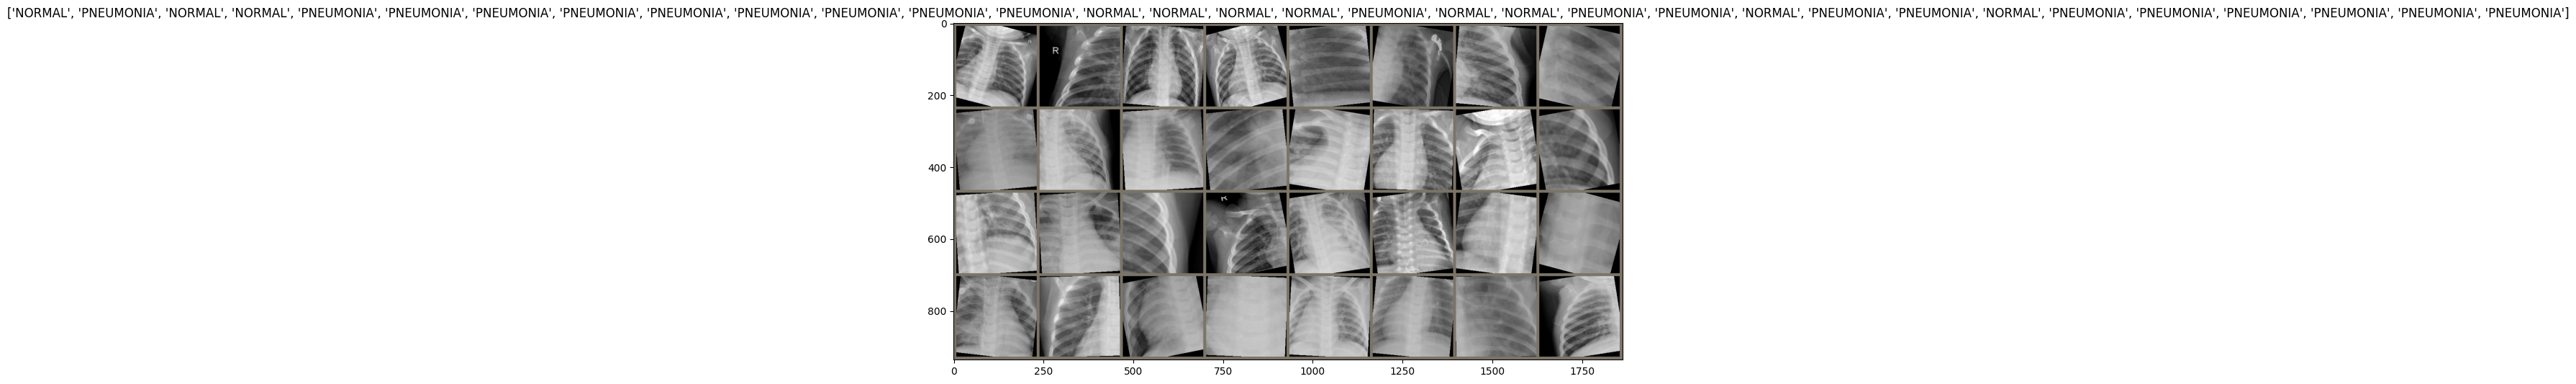

In [9]:
if __name__ == '__main__':
    dataloaders = main()
    

In [12]:
#开始训练
# 初始化记录器
history = {
    'test_loss': [],
    'test_acc': []
}
EPOCHS = 10
for epoch in range (1,EPOCHS+1):
    train_loss = train(model,DEVICE,dataloaders['train'],criterion,optimizer,epoch,writer=None)
    test_loss,test_acc = test(model,DEVICE,dataloaders['val'],criterion,epoch,writer=None)
    
    # 记录到 history 字典中
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

Test Epoch: 1 	Average Loss: 0.4266 	Accuracy: 87.18%
Test Epoch: 2 	Average Loss: 0.3843 	Accuracy: 88.30%
Test Epoch: 3 	Average Loss: 0.3736 	Accuracy: 87.18%
Test Epoch: 4 	Average Loss: 0.3975 	Accuracy: 87.18%
Test Epoch: 5 	Average Loss: 0.3576 	Accuracy: 87.82%
Test Epoch: 6 	Average Loss: 0.4502 	Accuracy: 86.22%
Test Epoch: 7 	Average Loss: 0.4443 	Accuracy: 85.90%
Test Epoch: 8 	Average Loss: 0.4404 	Accuracy: 87.02%
Test Epoch: 9 	Average Loss: 0.3885 	Accuracy: 87.50%
Test Epoch: 10 	Average Loss: 0.4167 	Accuracy: 87.18%


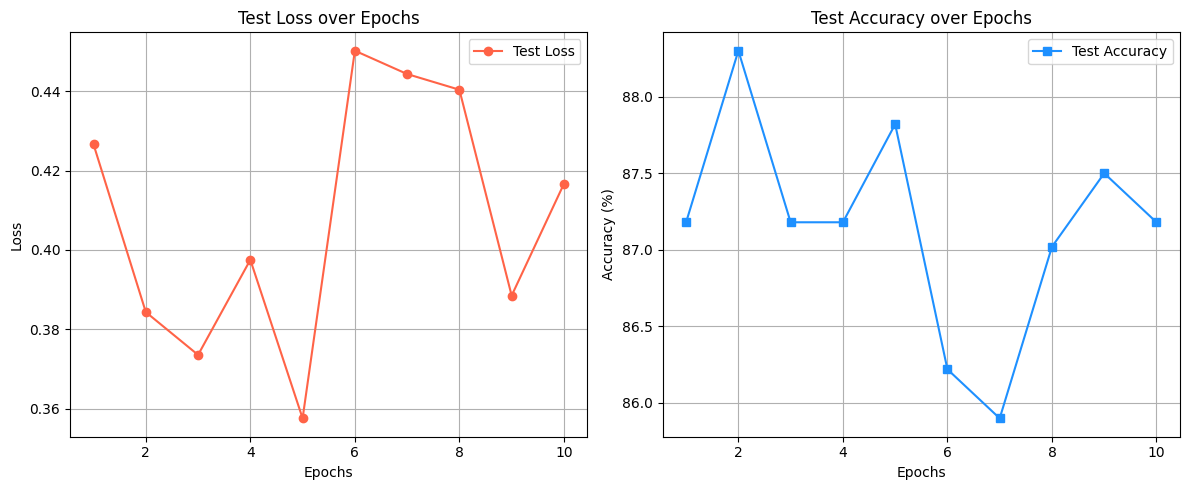

In [13]:
def plot_history(history):
    epochs = range(1, len(history['test_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # 绘制 Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['test_loss'], 'o-', color='tomato', label='Test Loss')
    plt.title('Test Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 绘制 Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['test_acc'], 's-', color='dodgerblue', label='Test Accuracy')
    plt.title('Test Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_performance.png') # 自动保存图片
    plt.show()

plot_history(history)